## text preprocessing on spam collection dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/sms-spam-collection-dataset


In [2]:
import pandas as pd
# Load data
df = pd.read_csv('/kaggle/input/sms-spam-collection-dataset/spam.csv', encoding='latin-1')
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### **Why Preprocess Text?**  
Raw text contains noise (punctuation, stopwords) that hurts model performance. We:  
1. Convert to lowercase.  
2. Remove all non whitespace and non word characters (puncutation)
3. Remove special characters/numbers/url.  
4. Tokenization
5. Eliminate stopwords ("the", "and").  
6. Stem words (e.g., "running" → "run").  
7. Lemmenatization

In [16]:
# Import Required Libraries
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Download NLTK Resources
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')

# Initialize Preprocessing Tools
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [17]:
# Clean Text (Remove URLs, special chars, lowercase)
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'https?://\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # Keep only letters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text

#  Tokenization, Stemming & Stopword Removal
def preprocess_text(text):
    text = clean_text(text)
    tokens = word_tokenize(text)
    stemmed = [stemmer.stem(word) for word in tokens if word not in stop_words]
    filtered = [word for word in stemmed if word not in stop_words]
    return filtered

#  Lemmatization with POS Tagging
def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {
        "J": wordnet.ADJ,
        "N": wordnet.NOUN,
        "V": wordnet.VERB,
        "R": wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token, get_wordnet_pos(token)) for token in tokens]


df = df.replace(to_replace=r'[^\w\s]', value='', regex=True)  # Remove punctuation
df = df.replace(to_replace=r'\d', value='', regex=True)       # Remove digits

# Apply the full pipeline
df['cleaned_text'] = df['text'].apply(preprocess_text)  # Clean → Tokenize → Stem → Remove Stopwords
df['lemmatized_messages'] = df['cleaned_text'].apply(lemmatize_tokens)  # Lemmatize


print(df[['text', 'cleaned_text', 'lemmatized_messages']].head())


                                                text  \
0  Go until jurong point crazy Available only in ...   
1                            Ok lar Joking wif u oni   
2  Free entry in  a wkly comp to win FA Cup final...   
3        U dun say so early hor U c already then say   
4  Nah I dont think he goes to usf he lives aroun...   

                                        cleaned_text  \
0  [go, jurong, point, crazi, avail, bugi, n, gre...   
1                       [ok, lar, joke, wif, u, oni]   
2  [free, entri, wkli, comp, win, fa, cup, final,...   
3      [u, dun, say, earli, hor, u, c, alreadi, say]   
4  [nah, dont, think, goe, usf, live, around, tho...   

                                 lemmatized_messages  
0  [go, jurong, point, crazi, avail, bugi, n, gre...  
1                       [ok, lar, joke, wif, u, oni]  
2  [free, entri, wkli, comp, win, fa, cup, final,...  
3      [u, dun, say, earli, hor, u, c, alreadi, say]  
4  [nah, dont, think, goe, usf, live, around, tho..

## sentiment classification model

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/sentiment-analysis-dataset


In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report





In [12]:
!pip install --upgrade scipy==1.13.1 numpy==1.26.4 --force-reinstall
!pip install gensim==4.3.3 --force-reinstall


  Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.1

In [3]:

from gensim.models import Word2Vec

# Download required NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [90]:
import pandas as pd

train_data = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/train.csv',
                 delimiter=',', encoding='ISO-8859-1')
test_data = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/test.csv',
                      delimiter=',', encoding='ISO-8859-1')
test_data.head()


,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [91]:
df = pd.concat([train_data,test_data])

In [92]:
df = df[['sentiment','text']]


In [93]:
df

,sentiment,text
0,neutral,"I`d have responded, if I were going"
1,negative,Sooo SAD I will miss you here in San Diego!!!
2,negative,my boss is bullying me...
3,negative,what interview! leave me alone
4,negative,"Sons of ****, why couldn`t they put them on t..."
...,...,...
4810,NaN,NaN
4811,NaN,NaN
4812,NaN,NaN
4813,NaN,NaN


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32296 entries, 0 to 4814
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  31015 non-null  object
 1   text       31014 non-null  object
dtypes: object(2)
memory usage: 756.9+ KB


## text preprocessing

In [95]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
# Initialize Preprocessing Tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [96]:
df.isnull().sum()

,0
sentiment,1281
text,1282


In [97]:
# Drop rows where sentiment or text is NaN
df = df.dropna(subset=['text', 'sentiment']).copy()

In [98]:
df.isnull().sum()

,0
sentiment,0
text,0


In [99]:
# Text Preprocessing Functions
def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'https?://\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # only letters
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

def preprocess_text(text):
    text = clean_text(text)
    tokens = word_tokenize(text)
    filtered = [word for word in tokens if word not in stop_words]
    return filtered

def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {
        "J": wordnet.ADJ,
        "N": wordnet.NOUN,
        "V": wordnet.VERB,
        "R": wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token, get_wordnet_pos(token)) for token in tokens]

# Preprocess text
df['cleaned_text'] = df['text'].apply(preprocess_text)
df['lemmatized_messages'] = df['cleaned_text'].apply(lemmatize_tokens)
df['processed_text'] = df['lemmatized_messages'].apply(lambda tokens: ' '.join(tokens))  # Prepare text for vectorizers (join tokens into string)


In [100]:
df.head()

,sentiment,text,cleaned_text,lemmatized_messages,processed_text
0,neutral,"I`d have responded, if I were going","[responded, going]","[respond, go]",respond go
1,negative,Sooo SAD I will miss you here in San Diego!!!,"[sooo, sad, miss, san, diego]","[sooo, sad, miss, san, diego]",sooo sad miss san diego
2,negative,my boss is bullying me...,"[boss, bullying]","[bos, bullying]",bos bullying
3,negative,what interview! leave me alone,"[interview, leave, alone]","[interview, leave, alone]",interview leave alone
4,negative,"Sons of ****, why couldn`t they put them on t...","[sons, put, releases, already, bought]","[son, put, release, already, bought]",son put release already bought


In [101]:
# Check unique sentiment labels
print(df['sentiment'].unique())

# Clean sentiment labels (remove extra spaces, unify casing)
df['sentiment'] = df['sentiment'].str.strip().str.capitalize()

# Map to numeric labels
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['sentiment'] = df['sentiment'].map(label_map)

# Check if mapping worked (no nulls)
print(df['sentiment'].isna().sum())


['neutral' 'negative' 'positive']
0


In [102]:
df.isnull().sum()

,0
sentiment,0
text,0
cleaned_text,0
lemmatized_messages,0
processed_text,0


In [103]:
X = df['processed_text']
y = df['sentiment']
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=df['sentiment'])

In [105]:
df['sentiment'].value_counts()

,count
sentiment,
1,12547
2,9685
0,8782


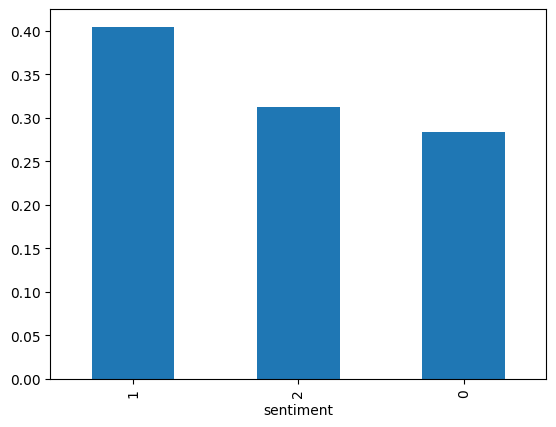

In [106]:
df['sentiment'].value_counts(normalize=True).plot(kind='bar');

In [116]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
# Evaluation function (for multiclass)
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    print(f"{model_name} Results:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted Precision: {prec:.4f}")
    print(f"Weighted Recall: {rec:.4f}")
    print(f"Weighted F1-Score: {f1:.4f}\n")

#Bag of Words
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

lr_bow = LogisticRegression(max_iter=1000 , n_jobs=-1)
lr_bow.fit(X_train_bow, y_train)
y_pred_bow = lr_bow.predict(X_test_bow)
evaluate_model(y_test, y_pred_bow, "Logistic Regression (BoW)")



Logistic Regression (BoW) Results:
Accuracy: 0.6997
Weighted Precision: 0.6993
Weighted Recall: 0.6997
Weighted F1-Score: 0.6994



In [114]:
print(classification_report(y_test, y_pred_bow))

              precision    recall  f1-score   support

           0       0.71      0.62      0.66      1756
           1       0.64      0.72      0.68      2510
           2       0.76      0.73      0.75      1937

    accuracy                           0.70      6203
   macro avg       0.71      0.69      0.70      6203
weighted avg       0.70      0.70      0.70      6203



In [108]:
# TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)
evaluate_model(y_test, y_pred_tfidf, "Logistic Regression (TF-IDF)")


Logistic Regression (TF-IDF) Results:
Accuracy: 0.6963
Weighted Precision: 0.7036
Weighted Recall: 0.6963
Weighted F1-Score: 0.6965



In [118]:
print(classification_report(y_test, y_pred_tfidf))

              precision    recall  f1-score   support

           0       0.73      0.61      0.66      1756
           1       0.63      0.74      0.68      2510
           2       0.78      0.72      0.75      1937

    accuracy                           0.70      6203
   macro avg       0.71      0.69      0.70      6203
weighted avg       0.70      0.70      0.70      6203



In [119]:
#  Word2Vec
# Train Word2Vec on training tokens
train_tokens = X_train.apply(lambda x: x.split()) # Now train_tokens is a Series of token lists
w2v_model = Word2Vec(sentences=train_tokens, vector_size=100, window=5, min_count=2, workers=4, seed=42) #100-dimensional vector ,(how many words before/after to consider), ignore words appearing less than 2 times

# to convert a document (list of tokens) into a single vector
def document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0: # if no token found
        return np.zeros(model.vector_size) # return zero
    return np.mean(vectors, axis=0) # else average

# Convert all documents into vectors
X_train_w2v = np.array([document_vector(doc.split(), w2v_model) for doc in X_train])
X_test_w2v = np.array([document_vector(doc.split(), w2v_model) for doc in X_test])

lr_w2v = LogisticRegression(max_iter=1000)
lr_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = lr_w2v.predict(X_test_w2v)
evaluate_model(y_test, y_pred_w2v, "Logistic Regression (Word2Vec)")

Logistic Regression (Word2Vec) Results:
Accuracy: 0.5584
Weighted Precision: 0.5856
Weighted Recall: 0.5584
Weighted F1-Score: 0.5437



In [121]:
print(classification_report(y_test, y_pred_w2v))

              precision    recall  f1-score   support

           0       0.62      0.31      0.41      1756
           1       0.50      0.76      0.61      2510
           2       0.66      0.52      0.58      1937

    accuracy                           0.56      6203
   macro avg       0.59      0.53      0.53      6203
weighted avg       0.59      0.56      0.54      6203

